# 3D Print Failure Detection - YOLOv26 Training

Train a custom YOLOv26 model to detect 3D print failures (spaghetti, stringing, zits) using a dataset from Roboflow.

This notebook can run on:
- **Google Colab** (free GPU)
- **Jupyter Lab / Notebook** (local GPU)

## Steps
1. Install dependencies
2. Download dataset from Roboflow
3. Train YOLOv26 model
4. Evaluate and test
5. Export trained weights

## 1. Install Dependencies

In [1]:
# %pip install ultralytics roboflow -q

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Verify GPU availability
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/(1024**3):,.2f} GB")
else:
    print("No GPU detected. Training will use CPU (much slower).")

PyTorch version: 2.7.1+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
VRAM: 23.54 GB


## 2. Download Dataset from Roboflow

Using the **3D Print Failure Detection** dataset by max.
- Classes: spaghetti, stringing, warping
- Format: YOLOv26

Get your API key from [Roboflow Settings](https://app.roboflow.com/settings/api).

In [2]:
!ls

3D-printing-failure-1  config.yaml	 runs		 yolo26n.pt
README.md	       img_display.py	 train.ipynb
__pycache__	       print_monitor.py  train.py
analyze_labels.py      requirements.txt  train_8K.ipynb


In [4]:
# # !pip install roboflow
# from roboflow import Roboflow
# rf = Roboflow(api_key="xxxxxxxxxxxxxxxxxxxxxx")
# project = rf.workspace("3d-printing-failure").project("3d-printing-failure")
# version = project.version(1)
# dataset = version.download("yolo26")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to 3D-printing-failure-1 in yolo26:: 100%|██████████| 17718/17718 [03:29<00:00, 84.74it/s] 


In [3]:
# Inspect dataset structure
import os

dataset_location =  "3D-printing-failure-1"

for root, dirs, files in os.walk(dataset_location):
    level = root.replace(dataset_location, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # Only show first 2 levels
        subindent = "  " * (level + 1)
        for file in files[:5]:
            print(f"{subindent}{file}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files) - 5} more files")

3D-printing-failure-1/
  data.yaml
  README.roboflow.txt
  README.dataset.txt
  .ipynb_checkpoints/
    data-checkpoint.yaml
  valid/
    labels.cache
    labels/
    images/
  train/
    labels.cache
    labels/
    images/
  test/
    labels/
    images/


In [4]:
# Read and display data.yaml
data_yaml_path = os.path.join(dataset_location, "data.yaml")

with open(data_yaml_path, "r") as f:
    print(f.read())

train: train/images
val: valid/images
test: test/images

nc: 3
names: ['spaghetti', 'stringing', 'zits']

roboflow:
  workspace: 3d-printing-failure
  project: 3d-printing-failure
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/3d-printing-failure/3d-printing-failure/dataset/1


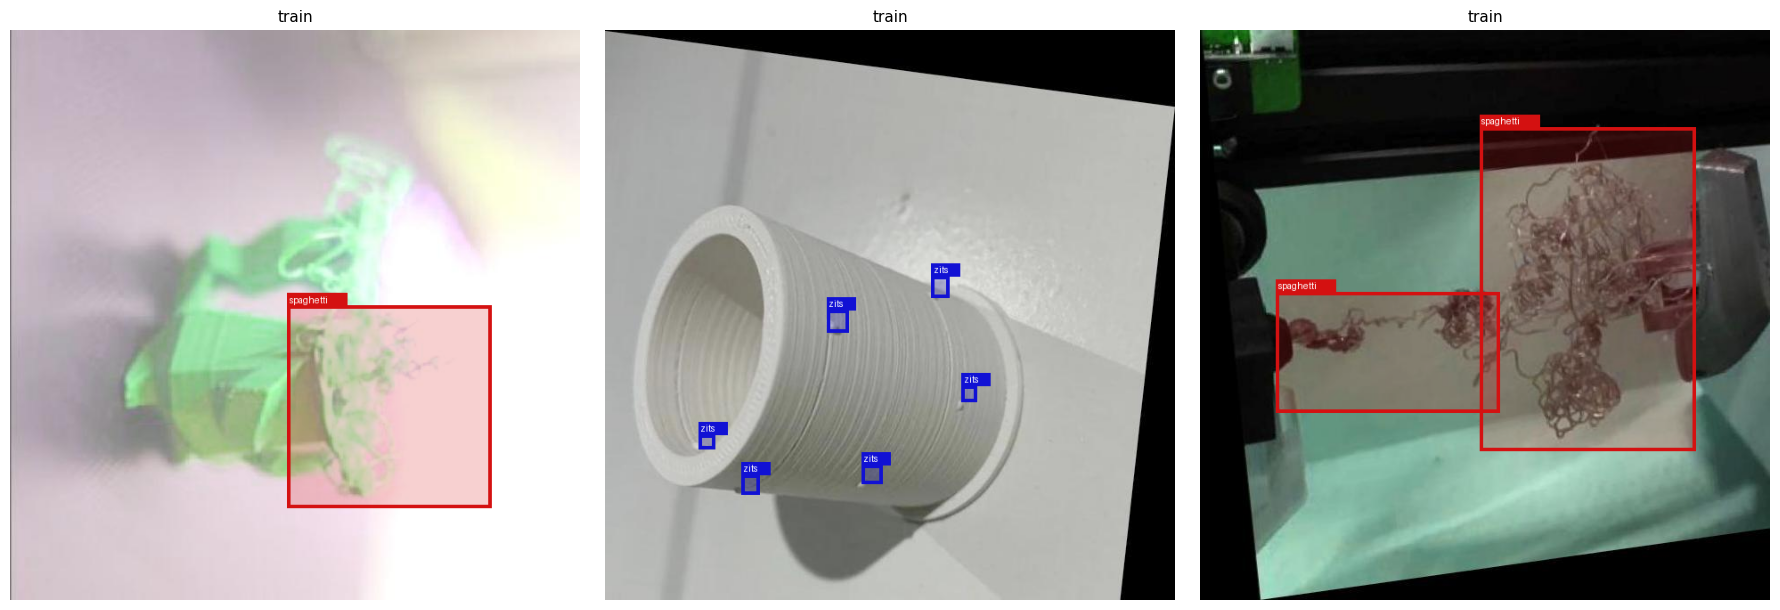

In [5]:
## Display some images
from img_display import show_samples

show_samples("3D-printing-failure-1/train", n=3)


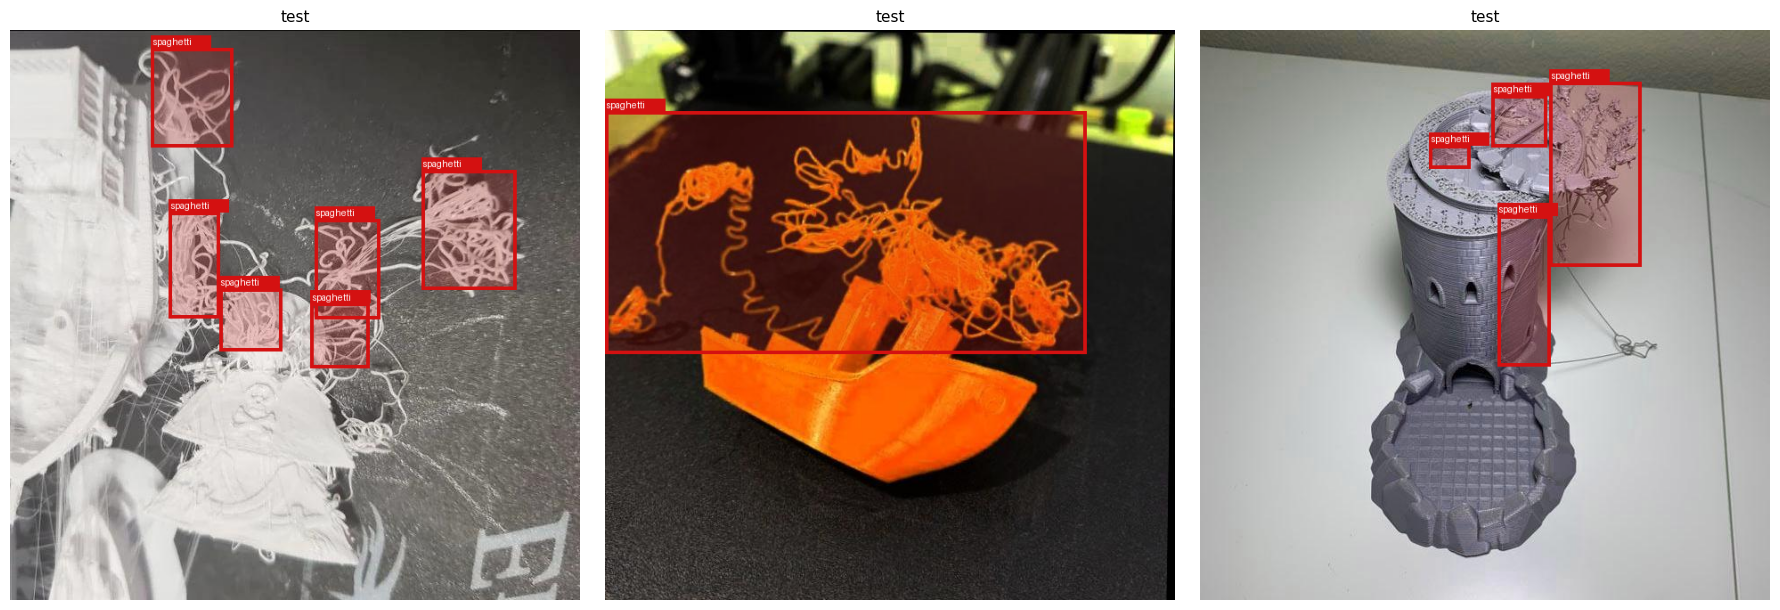

In [6]:
show_samples("3D-printing-failure-1/test", n=3)

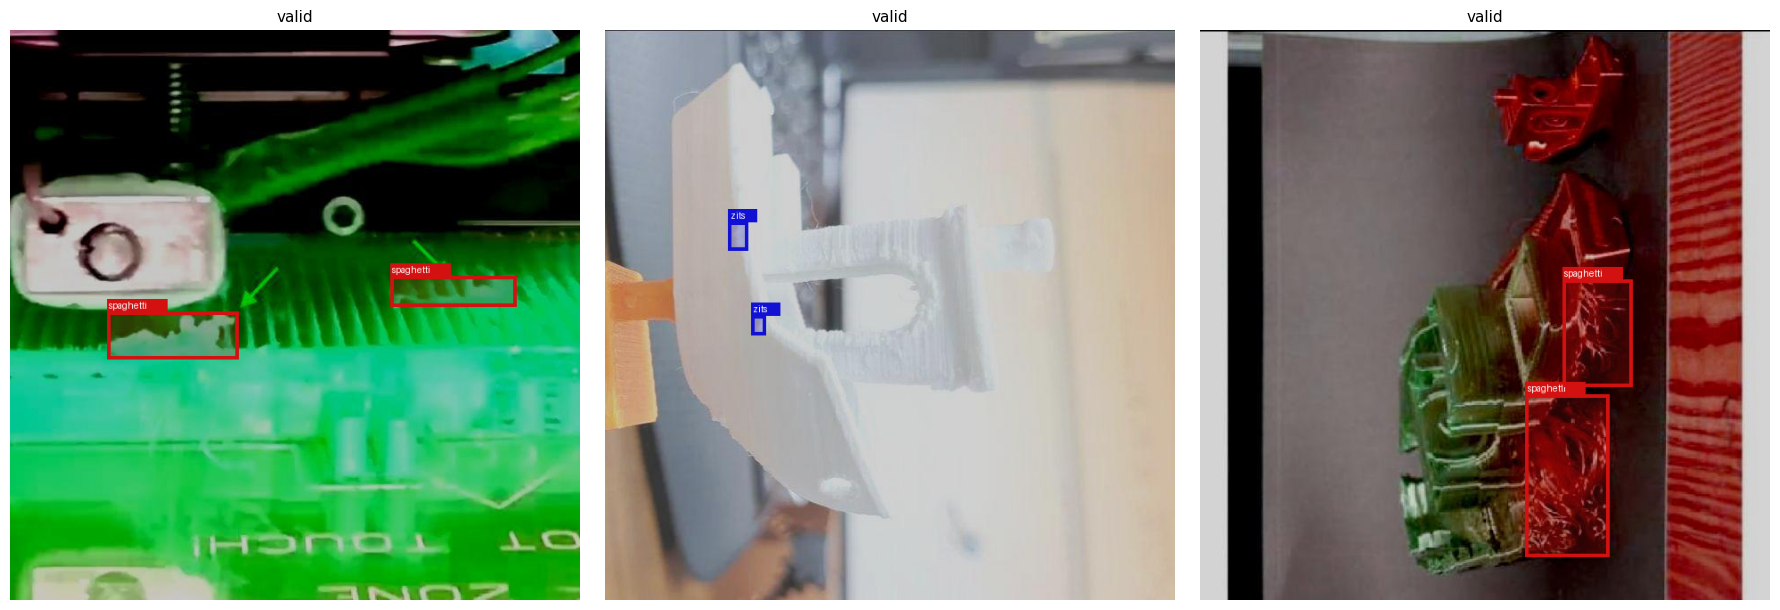

In [7]:
show_samples("3D-printing-failure-1/valid", n=3)

## ⚠️ Something is Wrong
Let's analyse why wrong results. mAP50 not increasing beyond 20%.

✅ Checklists:
 - `path in `data.yaml` with respect to project root
 - Labels exist for all?
 - Dataset imbalance
 - YOLO label format + Normalised?

### 1. Verify `data.yaml` file resolve correctly

In [8]:
import yaml, os, glob

with open(os.path.join(dataset_location, "data.yaml")) as f:
    cfg = yaml.safe_load(f)

for split in ["train", "val", "test"]:
    img_dir = os.path.normpath(os.path.join(dataset_location, cfg[split]))
    imgs = glob.glob(os.path.join(img_dir, "*.*"))
    print(f"{split}: {len(imgs)} images  →  {img_dir}")
    assert len(imgs) > 0, f"⚠️ NO IMAGES FOUND for {split}!"


train: 6159 images  →  3D-printing-failure-1/train/images
val: 1346 images  →  3D-printing-failure-1/valid/images
test: 1348 images  →  3D-printing-failure-1/test/images


### 2. 🐞Debug: print what `data.yaml` says vs what actually exists


In [9]:
with open(os.path.join(dataset_location, "data.yaml")) as f:
    cfg = yaml.safe_load(f)

print(f"CWD:              {os.getcwd()}")
print(f"dataset_location: {dataset_location}")
print(f"data.yaml paths:")
for split in ["train", "val", "test"]:
    raw = cfg[split]
    resolved = os.path.normpath(os.path.join(dataset_location, raw))
    exists = os.path.isdir(resolved)
    print(f"  {split}: '{raw}'  →  {resolved}  →  exists={exists}")

# Also show what folders DO exist in the dataset
print(f"\nActual contents of {dataset_location}:")
for item in os.listdir(dataset_location):
    full = os.path.join(dataset_location, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f"  📁 {item}/ ({count} items)")
    else:
        print(f"  📄 {item}")


CWD:              /workspace/3dPrint/src
dataset_location: 3D-printing-failure-1
data.yaml paths:
  train: 'train/images'  →  3D-printing-failure-1/train/images  →  exists=True
  val: 'valid/images'  →  3D-printing-failure-1/valid/images  →  exists=True
  test: 'test/images'  →  3D-printing-failure-1/test/images  →  exists=True

Actual contents of 3D-printing-failure-1:
  📁 .ipynb_checkpoints/ (1 items)
  📁 valid/ (3 items)
  📁 train/ (3 items)
  📁 test/ (2 items)
  📄 data.yaml
  📄 README.roboflow.txt
  📄 README.dataset.txt


### 3. Check Labels Exists and are not Empty

In [10]:
# Do label files actually exist alongside images?
train_img_dir = os.path.normpath(os.path.join(dataset_location, cfg["train"]))
train_lbl_dir = train_img_dir.replace("images", "labels")

imgs = glob.glob(os.path.join(train_img_dir, "*.*"))
empty, missing = 0, 0
for img in imgs:
    lbl = os.path.join(train_lbl_dir, os.path.splitext(os.path.basename(img))[0] + ".txt")
    if not os.path.exists(lbl):
        missing += 1
    elif os.path.getsize(lbl) == 0:
        empty += 1

print(f"Total images: {len(imgs)}")
print(f"Missing labels: {missing}")
print(f"Empty labels (background): {empty}")
print(f"Labeled images: {len(imgs) - missing - empty}")


Total images: 6159
Missing labels: 0
Empty labels (background): 1
Labeled images: 6158


### 4. Validate label format ( Must be Normalized)

In [11]:
import random

# Pick a random label and inspect
lbls = glob.glob(os.path.join(train_lbl_dir, "*.txt"))
sample = random.choice([l for l in lbls if os.path.getsize(l) > 0])
print(f"Sample: {sample}\n")
with open(sample) as f:
    for line in f:
        parts = line.strip().split()
        print(f"  class={parts[0]}  cx={parts[1]}  cy={parts[2]}  w={parts[3]}  h={parts[4]}")
        # ALL values after class should be between 0.0 and 1.0
        for v in parts[1:]:
            assert 0.0 <= float(v) <= 1.0, f"⚠️ VALUE {v} OUT OF RANGE — labels may be pixel coords, not normalized!"
print("\n✅ Format looks correct")


Sample: 3D-printing-failure-1/train/labels/imag-72-_jpg.rf.c9bef1852ac9d23ebf95eeeb72cbf288.txt

  class=0  cx=0.3390625  cy=0.7140625  w=0.2703125  h=0.3125
  class=0  cx=0.10078125  cy=0.51171875  w=0.1953125  h=0.721875

✅ Format looks correct


### 5. Check Class Distribution (Imbalance?)

In [12]:
from collections import Counter

class_counts = Counter()
for lbl in glob.glob(os.path.join(train_lbl_dir, "*.txt")):
    with open(lbl) as f:
        for line in f:
            cls = int(line.strip().split()[0])
            class_counts[cls] += 1

print("Class distribution:")
for cls_id, count in sorted(class_counts.items()):
    print(f"  {cfg['names'][cls_id]:>12s} (class {cls_id}): {count} instances")


Class distribution:
     spaghetti (class 0): 9794 instances
     stringing (class 1): 2380 instances
          zits (class 2): 31336 instances


Huge imbalance observed. 

Measures:
 - cosine LR schedule (gentler decay)
 - augment = True (mosaic + mixup)


## Train Now

Using 4090 24 GB

In [13]:
from ultralytics import YOLO

# Load pretrained YOLOv26 nano model
model = YOLO("yolo26n.pt")

results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=1024,          # 1024: BIGGEST lever for tiny zits on 4090, we observed mAP not improving in 100 epochs for 640p and 800p earlier
    batch=32,            # batch=16 on 24GB, may increase later of overhead remains
    name="print_failure_detector_v26_nano_4090",
    cos_lr=True,
    patience=20,
    save=True,
    plots=True,

    # Loss weights
    box=8.5,
    cls=1.0,

    # Augmentation
    mosaic=1.0,
    close_mosaic=15,
    mixup=0.15,
    copy_paste=0.15,
    scale=0.7,
    degrees=10.0,
    shear=2.0,
    flipud=0.1,
    hsv_h=0.02,
    hsv_s=0.75,
    hsv_v=0.5,
    erasing=0.3,
)


Ultralytics 8.4.39 🚀 Python-3.11.13 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4090, 24107MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=8.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=1.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.15, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=3D-printing-failure-1/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.3, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.75, hsv_v=0.5, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=print_failure_detector_v26_nano_4090, nbs=64, nms=False, opset=None, optimize=Fals

## 5. Evaluate Model


In [14]:
# from ultralytics import YOLO

# Load the best weights
best_model = YOLO("runs/detect/print_failure_detector_v26_nano_4090/weights/best.pt")

# Run validation
metrics = best_model.val()

print(f"\nmAP@0.5:      {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")

Ultralytics 8.4.39 🚀 Python-3.11.13 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4090, 24107MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 4.4±6.8 ms, read: 2.3±2.4 MB/s, size: 28.2 KB)

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 141, len(boxes) = 10030. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 85/85 12.9it/s 6.6s
                   all       1346      10030      0.809      0.679      0.749      0.415
             spaghetti        956       2182      0.935      0.948       0.98       0.67
             stringing        148        586      0.778      0.669      0.743      0.379
                  zits        251       7262      0.714       0.42     

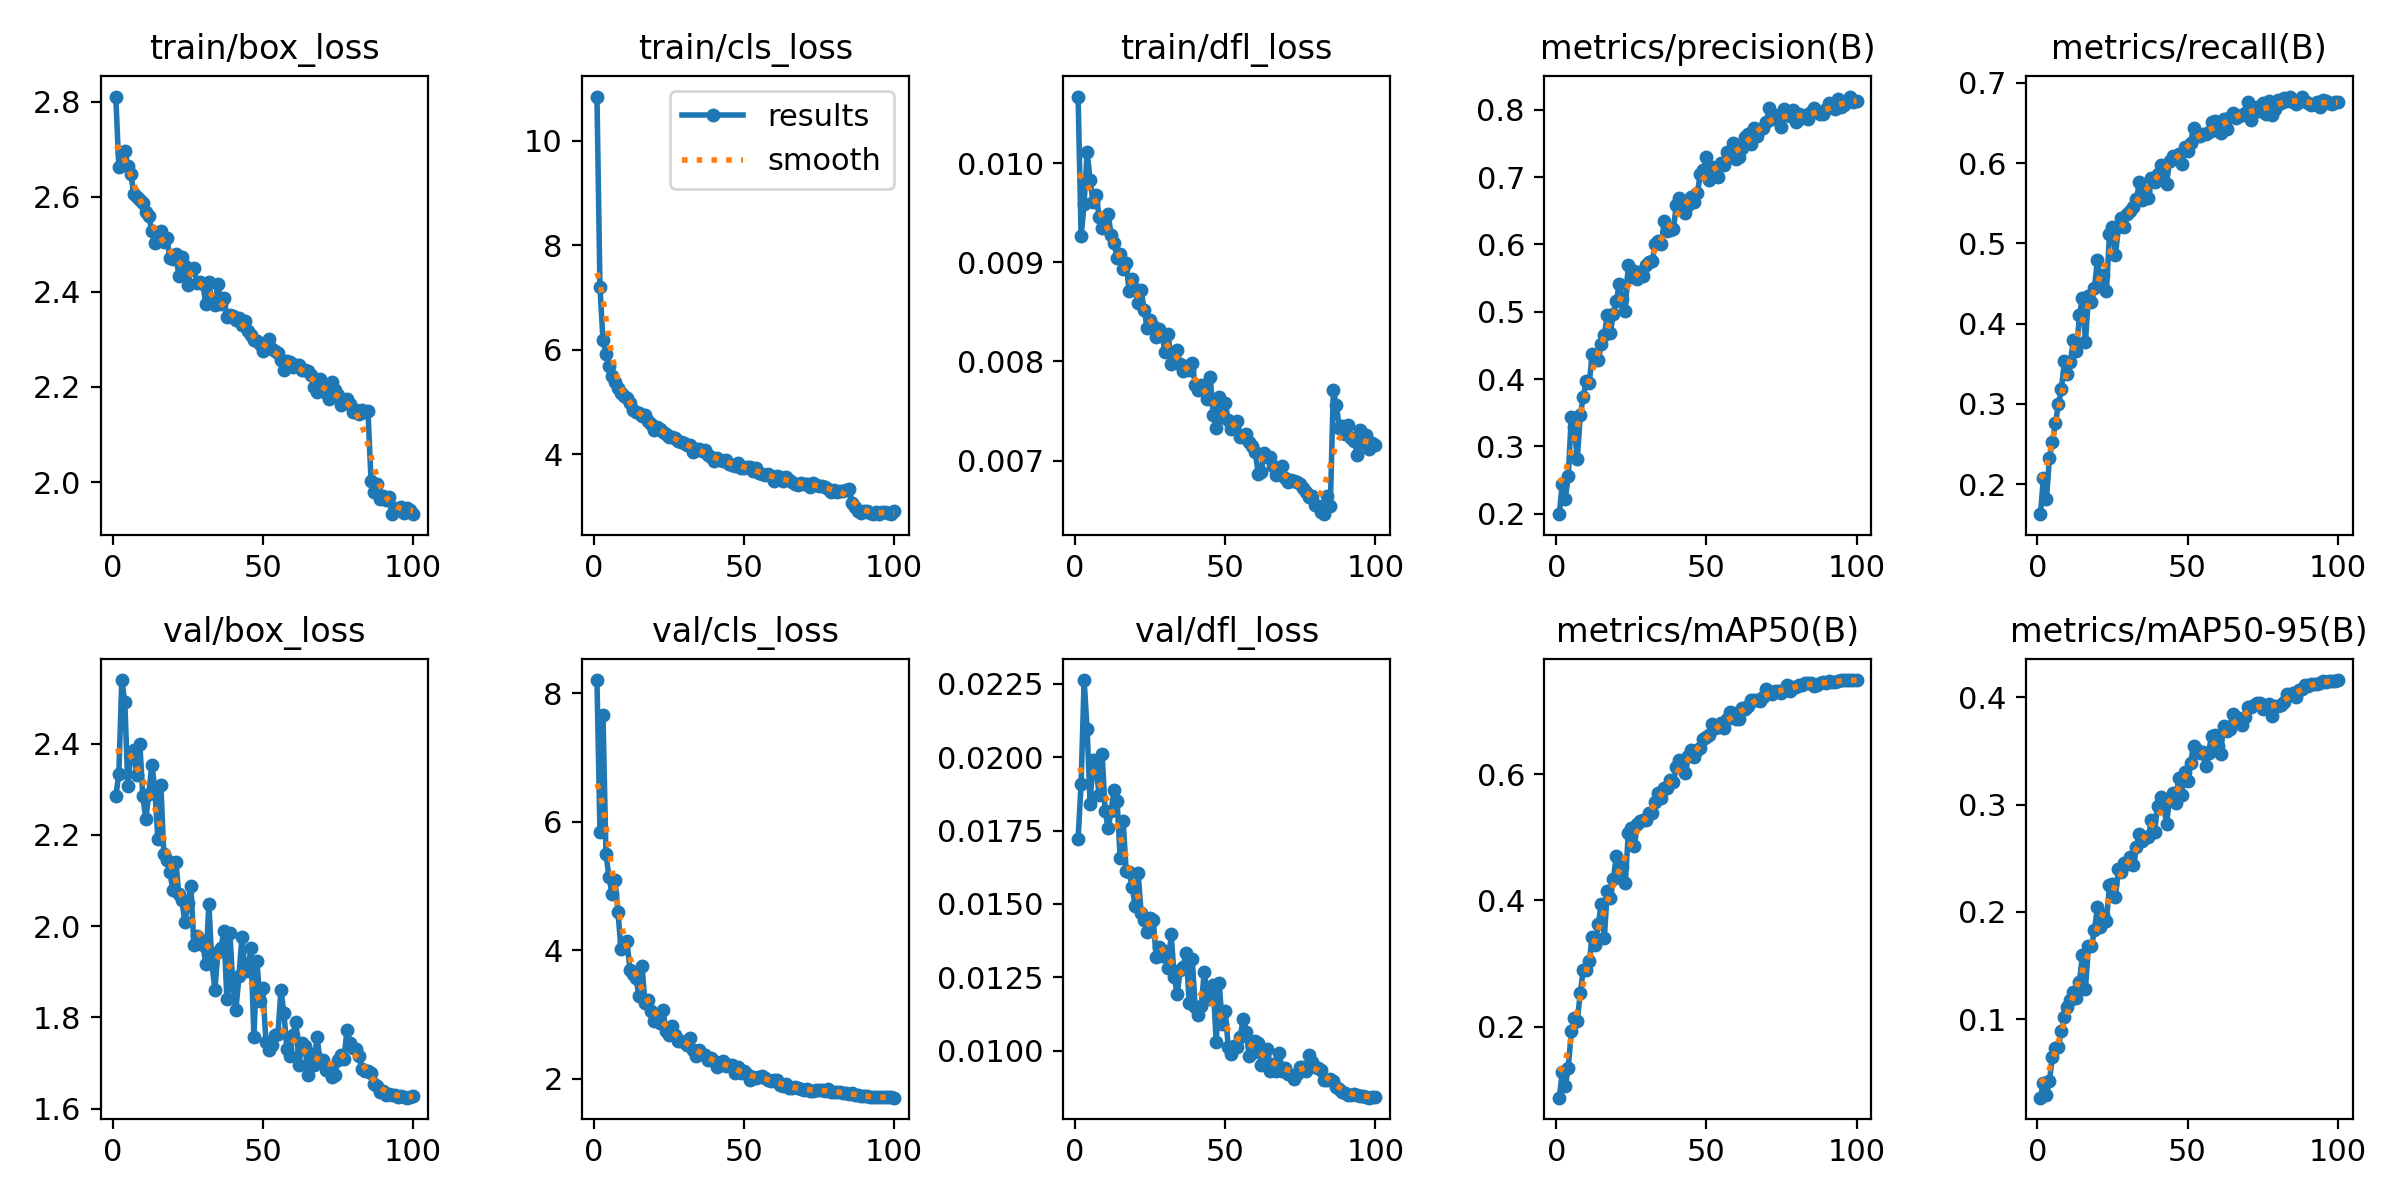

In [17]:
# Display training results
from IPython.display import Image, display

# Training curves
results_img = "runs/detect/print_failure_detector_v26_nano_4090/results.png"
if os.path.exists(results_img):
    display(Image(filename=results_img, width=800))
else:
    print(f"Results image not found at {results_img}")

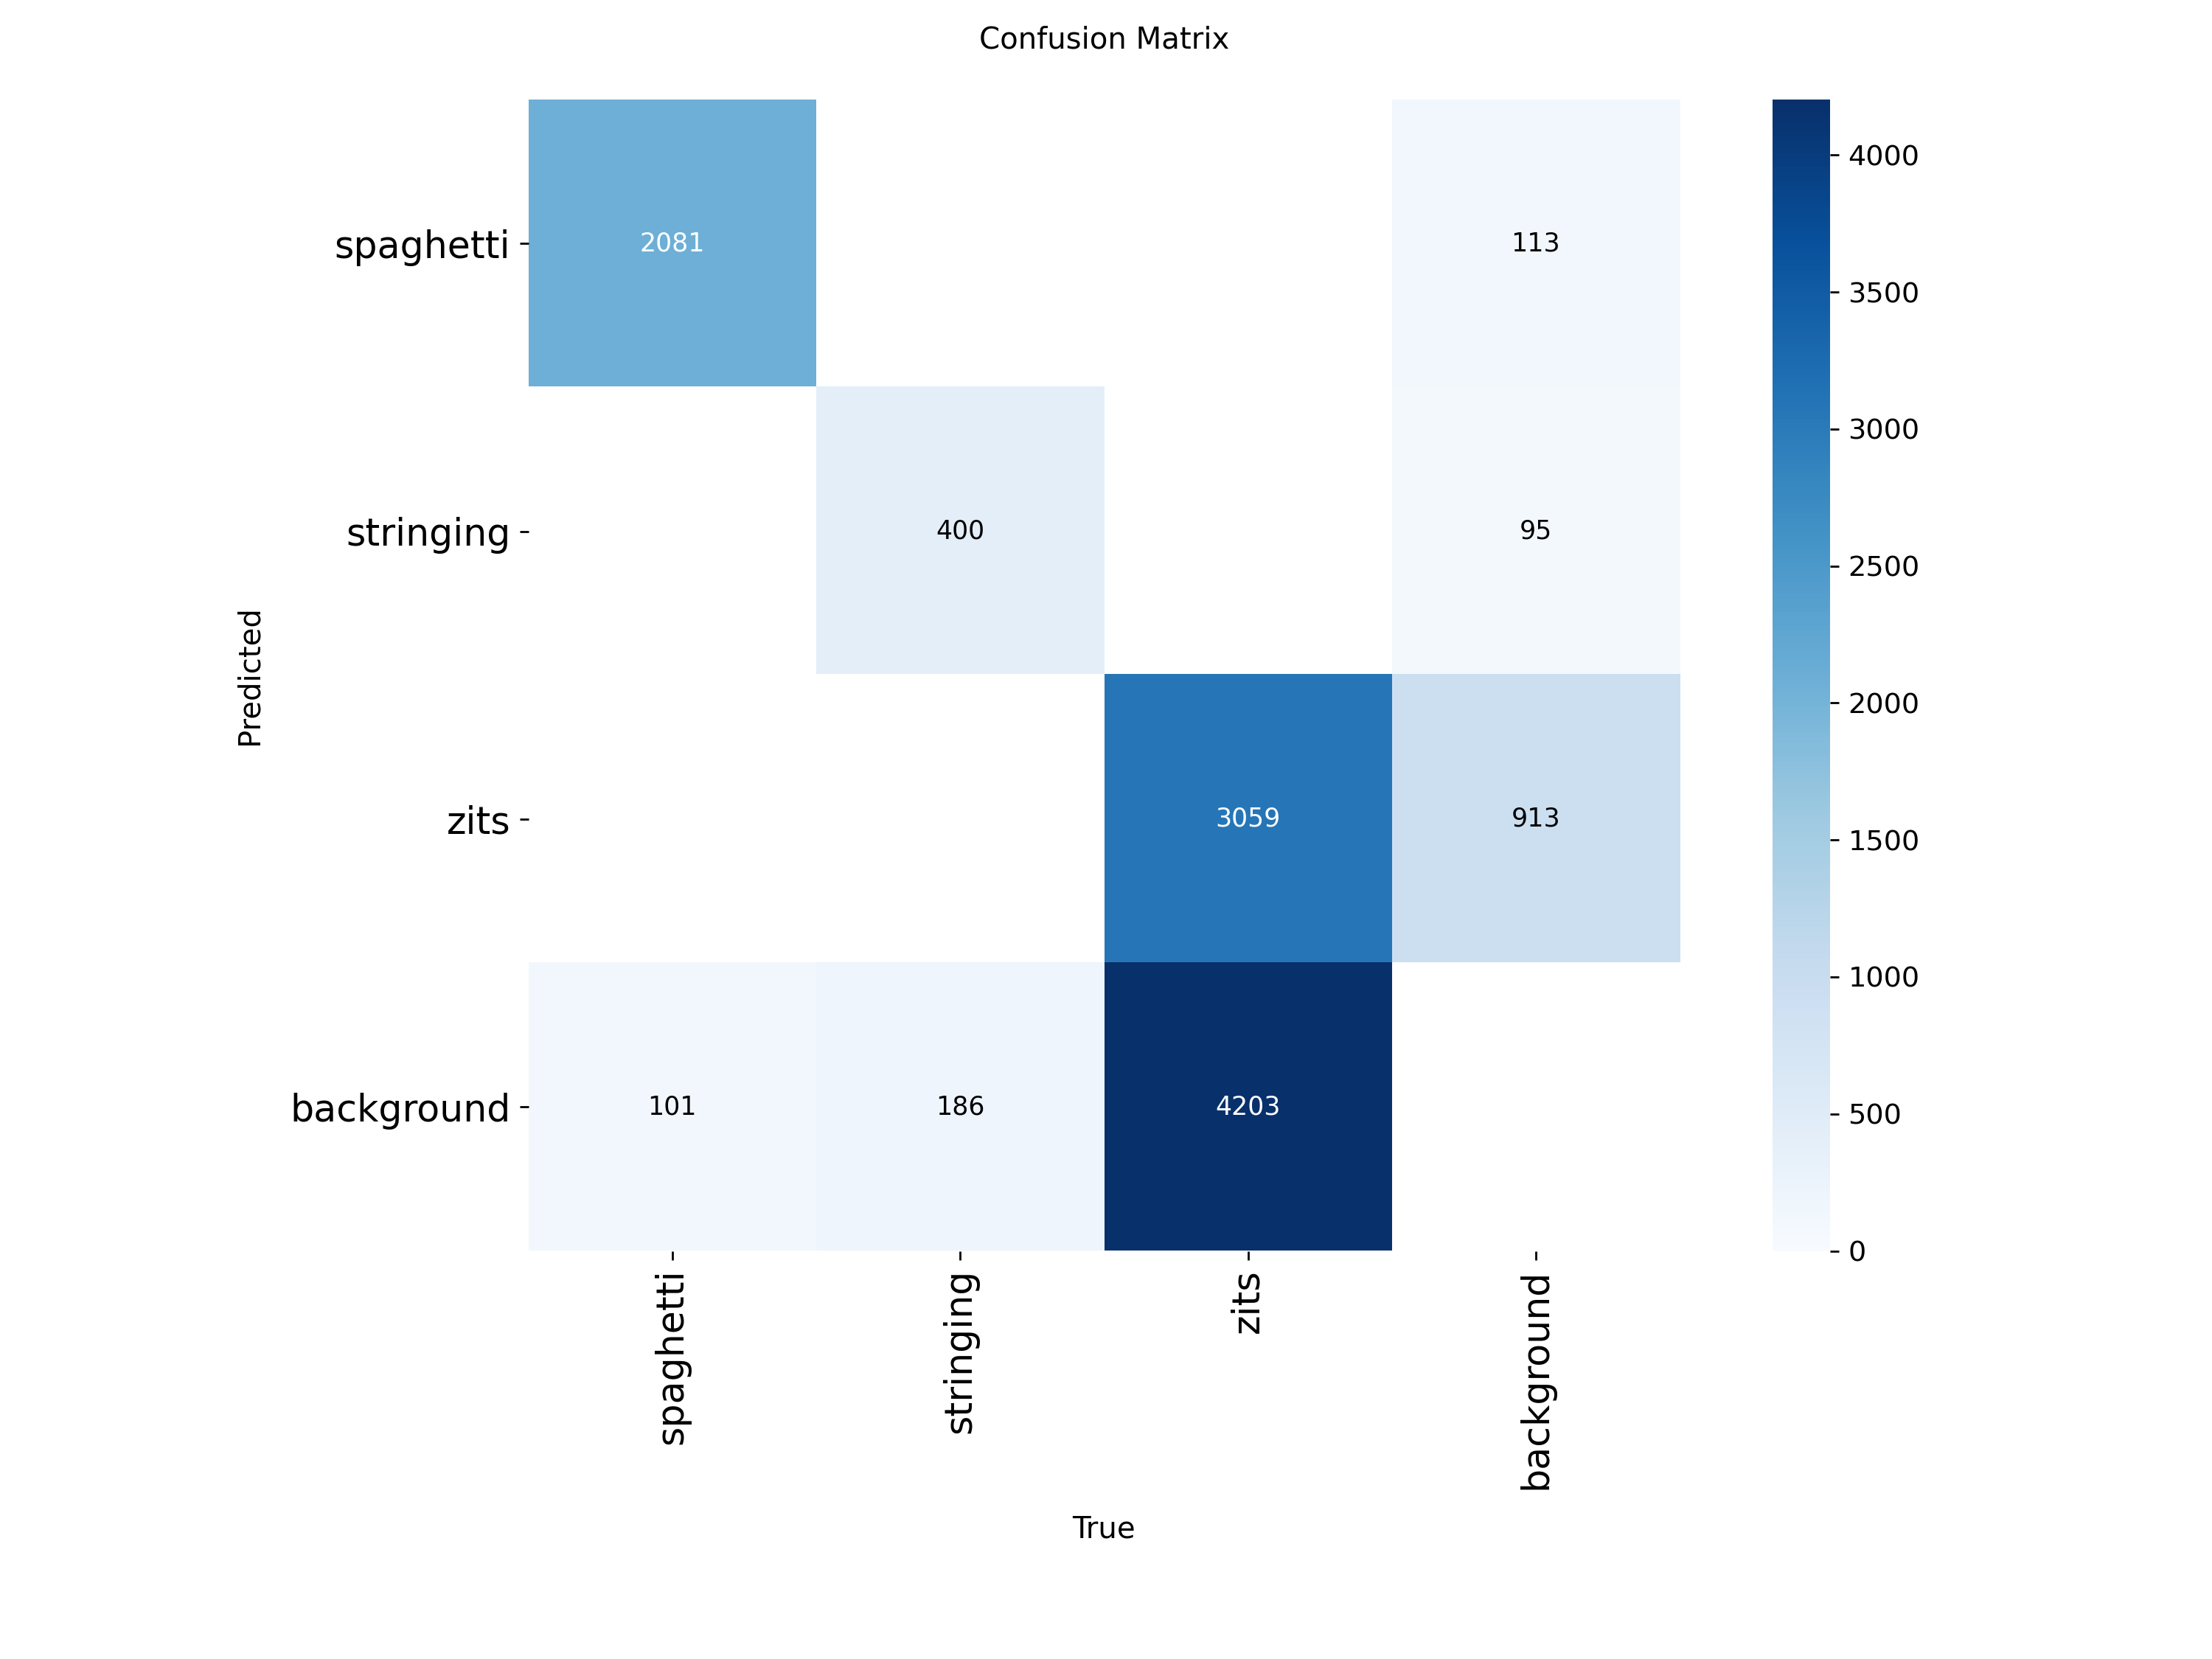

In [18]:
# Confusion matrix
cm_img = "runs/detect/print_failure_detector_v26_nano_4090/confusion_matrix.png"
if os.path.exists(cm_img):
    display(Image(filename=cm_img, width=600))
else:
    print(f"Confusion matrix not found at {cm_img}")

`Spaghetti` detection is strong but rest needs improvement. Let's retrain for longer with augmentation and see how it improves. We will continue from current checkpoint.

## 6. Export Model

The trained weights are saved at:
```
runs/detect/print_failure_detector/weights/best.pt
```

Download this file and place it in your `PrintFailureDetection/` directory to use with `print_monitor.py`.

In [20]:
# Export to ONNX (optional, for deployment on edge devices)
best_model.export(format="onnx")

print("Best weights location:")
weights_path = "runs/detect/print_failure_detector_v26_nano_4090/weights/best.pt"
if os.path.exists(weights_path):
    size_mb = os.path.getsize(weights_path) / (1024 * 1024)
    print(f"  {weights_path} ({size_mb:.1f} MB)")
else:
    print(f"  Weights not found at {weights_path}")

print("\nTraining complete! Download best.pt and run:")
print("  python print_monitor.py")

Ultralytics 8.4.39 🚀 Python-3.11.13 torch-2.7.1+cu126 CPU (AMD Ryzen 9 7950X 16-Core Processor)

PyTorch: starting from 'runs/detect/print_failure_detector_v26_nano_4090/weights/best.pt' with input shape (1, 3, 1024, 1024) BCHW and output shape(s) (1, 300, 6) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/17.6 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━ 12.6/17.6 MB 90.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/252.8 MB ? eta -:--:--
   ━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/252.8 MB 257.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━ 100.7/252.8 MB 251.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━ 143.7/252.8 MB 239.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━ 185.9/2

/opt/conda/lib/python3.11/site-packages/torch/onnx/symbolic_opset9.py:5350: UserWarning: Exporting aten::index operator of advanced indexing in opset 19 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(


ONNX: export success ✅ 6.6s, saved as 'runs/detect/print_failure_detector_v26_nano_4090/weights/best.onnx' (9.6 MB)

Export complete (6.8s)
Results saved to /workspace/3dPrint/src/runs/detect/print_failure_detector_v26_nano_4090/weights
Predict:         yolo predict task=detect model=runs/detect/print_failure_detector_v26_nano_4090/weights/best.onnx imgsz=1024 
Validate:        yolo val task=detect model=runs/detect/print_failure_detector_v26_nano_4090/weights/best.onnx imgsz=1024 data=3D-printing-failure-1/data.yaml  
Visualize:       https://netron.app
Best weights location:
  runs/detect/print_failure_detector_v26_nano_4090/weights/best.pt (5.2 MB)

Training complete! Download best.pt and run:
  python print_monitor.py


---

## Quick Reference

| Metric | What it means |
|--------|---------------|
| **mAP@0.5** | Accuracy at 50% IoU threshold (main metric) |
| **mAP@0.5:0.95** | Average accuracy across IoU thresholds |
| **Recall** | What fraction of real failures are detected |
| **Precision** | What fraction of detections are correct |

**Target:** mAP@0.5 > 0.7 for usable detection. Prioritize **high recall for spaghetti** (better to false alarm than miss a real failure).